# A股全天候组合

季度再平衡的多资产组合；30年国债腿由中债指数与真实 ETF 拼接。

In [1]:
import os, sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
warnings.filterwarnings('ignore')
_ROOT = Path.cwd().resolve()
while not (_ROOT / 'pyproject.toml').exists(): _ROOT = _ROOT.parent
os.chdir(_ROOT); sys.path.insert(0, str(_ROOT))
pd.set_option('display.width', 220); pd.set_option('display.max_columns', 40)
pd.set_option('display.max_rows', 200)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.sans-serif'] = ['Hiragino Sans GB', 'Arial Unicode MS', 'STHeiti', 'Songti SC']
plt.rcParams['axes.unicode_minus'] = False
print('Root:', _ROOT)

Root: /Users/riceball/Documents/Projs/fund


In [2]:
from dataload.all_weather import load_all_weather_data, ASSET_MAP, BENCH_MAP, ALL_CODES
from strategy.all_weather import TARGET_WEIGHTS, BENCH_6040_WEIGHTS
from backtest.weights import quarterly_rebalance_dates, run_weight_backtest
from backtest.metrics import calc_perf, monthly_returns
BT_START = pd.Timestamp('2013-07-29')
BT_END = pd.Timestamp('2026-09-18')
INITIAL_CAPITAL = 1_000_000.0
COMMISSION, STAMP_TAX = 0.0003, 0.0005
print(f'Backtest: {BT_START.date()} ~ {BT_END.date()}')
print(f'Initial capital: {INITIAL_CAPITAL:,.0f}')
print('Target weights:', TARGET_WEIGHTS)
print('60/40 weights:', BENCH_6040_WEIGHTS)
print(f'Costs: commission={COMMISSION:.4%} stamp_tax={STAMP_TAX:.4%}')
print('30年国债腿: 2013-07-29~2023-06-12 用CBA21801指数代理, 06-13起用511090真实ETF(缩放衔接)')

Backtest: 2013-07-29 ~ 2026-09-18
Initial capital: 1,000,000
Target weights: {'000510': 0.25, '510880': 0.1, '0030Y': 0.3, '518880': 0.15, '511880': 0.2}
60/40 weights: {'000300': 0.6, '000012': 0.4}
Costs: commission=0.0300% stamp_tax=0.0500%
30年国债腿: 2013-07-29~2023-06-12 用CBA21801指数代理, 06-13起用511090真实ETF(缩放衔接)


In [3]:
all_data = load_all_weather_data(BT_START, BT_END)
all_days = sorted(set(d for df in all_data.values() for d in df.index))
all_days = [d for d in all_days if BT_START <= d]
rebal_dates = quarterly_rebalance_dates(all_days, BT_START, BT_END)
print(f'Rebalance dates: {len(rebal_dates)}')
print([d.date() for d in rebal_dates])

OK(qq)   510880: 3198 rows, 2013-07-29 ~ 2026-09-18
OK(qq)   518880: 3198 rows, 2013-07-29 ~ 2026-09-18
OK(qq)   511880: 3198 rows, 2013-07-29 ~ 2026-09-18
OK(qq)   511090: 795 rows, 2023-06-13 ~ 2026-09-18
OK(sina) 000300: 3198 rows, 2013-07-29 ~ 2026-09-18
OK(sina) 000012: 3198 rows, 2013-07-29 ~ 2026-09-18
OK(sina) 000510: 3198 rows, 2013-07-29 ~ 2026-09-18
OK(proxy) 0030Y: 3198 rows, 2013-07-29 ~ 2026-09-18, scale=2.1279

Loaded 8 assets
Available: ['510880', '518880', '511880', '511090', '000300', '000012', '000510', '0030Y']
Rebalance dates: 53
[datetime.date(2013, 7, 29), datetime.date(2013, 10, 8), datetime.date(2014, 1, 2), datetime.date(2014, 4, 1), datetime.date(2014, 7, 1), datetime.date(2014, 10, 8), datetime.date(2015, 1, 5), datetime.date(2015, 4, 1), datetime.date(2015, 7, 1), datetime.date(2015, 10, 8), datetime.date(2016, 1, 4), datetime.date(2016, 4, 1), datetime.date(2016, 7, 1), datetime.date(2016, 10, 10), datetime.date(2017, 1, 3), datetime.date(2017, 4, 5), date

In [4]:
print('=== A股全天候组合 ===')
bt_aw = run_weight_backtest(all_data, TARGET_WEIGHTS, rebal_dates,
                            init_cap=INITIAL_CAPITAL, comm=COMMISSION, tax=STAMP_TAX)
print(f'  NAV end: {bt_aw.daily_nav.iloc[-1]:.4f}')
print(f'  Total cost: {bt_aw.total_cost:,.0f}')
print(f'  Trades: {len(bt_aw.trades)}')

print('\n=== Benchmark: CSI300 Buy & Hold ===')
bench_300_nav = None
if '000300' in all_data:
    b300 = all_data['000300']
    b300 = b300[(b300.index >= BT_START) & (b300.index <= BT_END)]
    bench_300_nav = b300['close'] / b300['close'].iloc[0]
    print(f'  NAV end: {bench_300_nav.iloc[-1]:.4f}')
else:
    print('  No CSI300 data')

print('\n=== Benchmark: 60/40 Quarterly ===')
bt_6040 = run_weight_backtest(all_data, BENCH_6040_WEIGHTS, rebal_dates,
                              init_cap=INITIAL_CAPITAL, comm=COMMISSION, tax=STAMP_TAX)
print(f'  NAV end: {bt_6040.daily_nav.iloc[-1]:.4f}')
print(f'  Total cost: {bt_6040.total_cost:,.0f}')

=== A股全天候组合 ===


  NAV end: 3.2252
  Total cost: 3,418
  Trades: 281

=== Benchmark: CSI300 Buy & Hold ===


  NAV end: 2.0714

=== Benchmark: 60/40 Quarterly ===
  NAV end: 2.1662
  Total cost: 2,161


In [5]:
results = [calc_perf(bt_aw.daily_nav, 'A股全天候')]
if bench_300_nav is not None: results.append(calc_perf(bench_300_nav, '沪深300买入持有'))
results.append(calc_perf(bt_6040.daily_nav, '60/40组合'))
perf_df = pd.DataFrame(results).set_index('name')
print(perf_df.round(4).to_string())

           cumulative  annual_return  annual_vol  sharpe  sortino  calmar  max_drawdown
name                                                                                   
A股全天候          2.2252         0.0985      0.0928  0.8467   1.0869  0.3796       -0.2069
沪深300买入持有      1.0714         0.0591      0.2124  0.1840   0.2369  0.0837       -0.4670
60/40组合        1.1662         0.0640      0.1270  0.3466   0.4461  0.1471       -0.2992


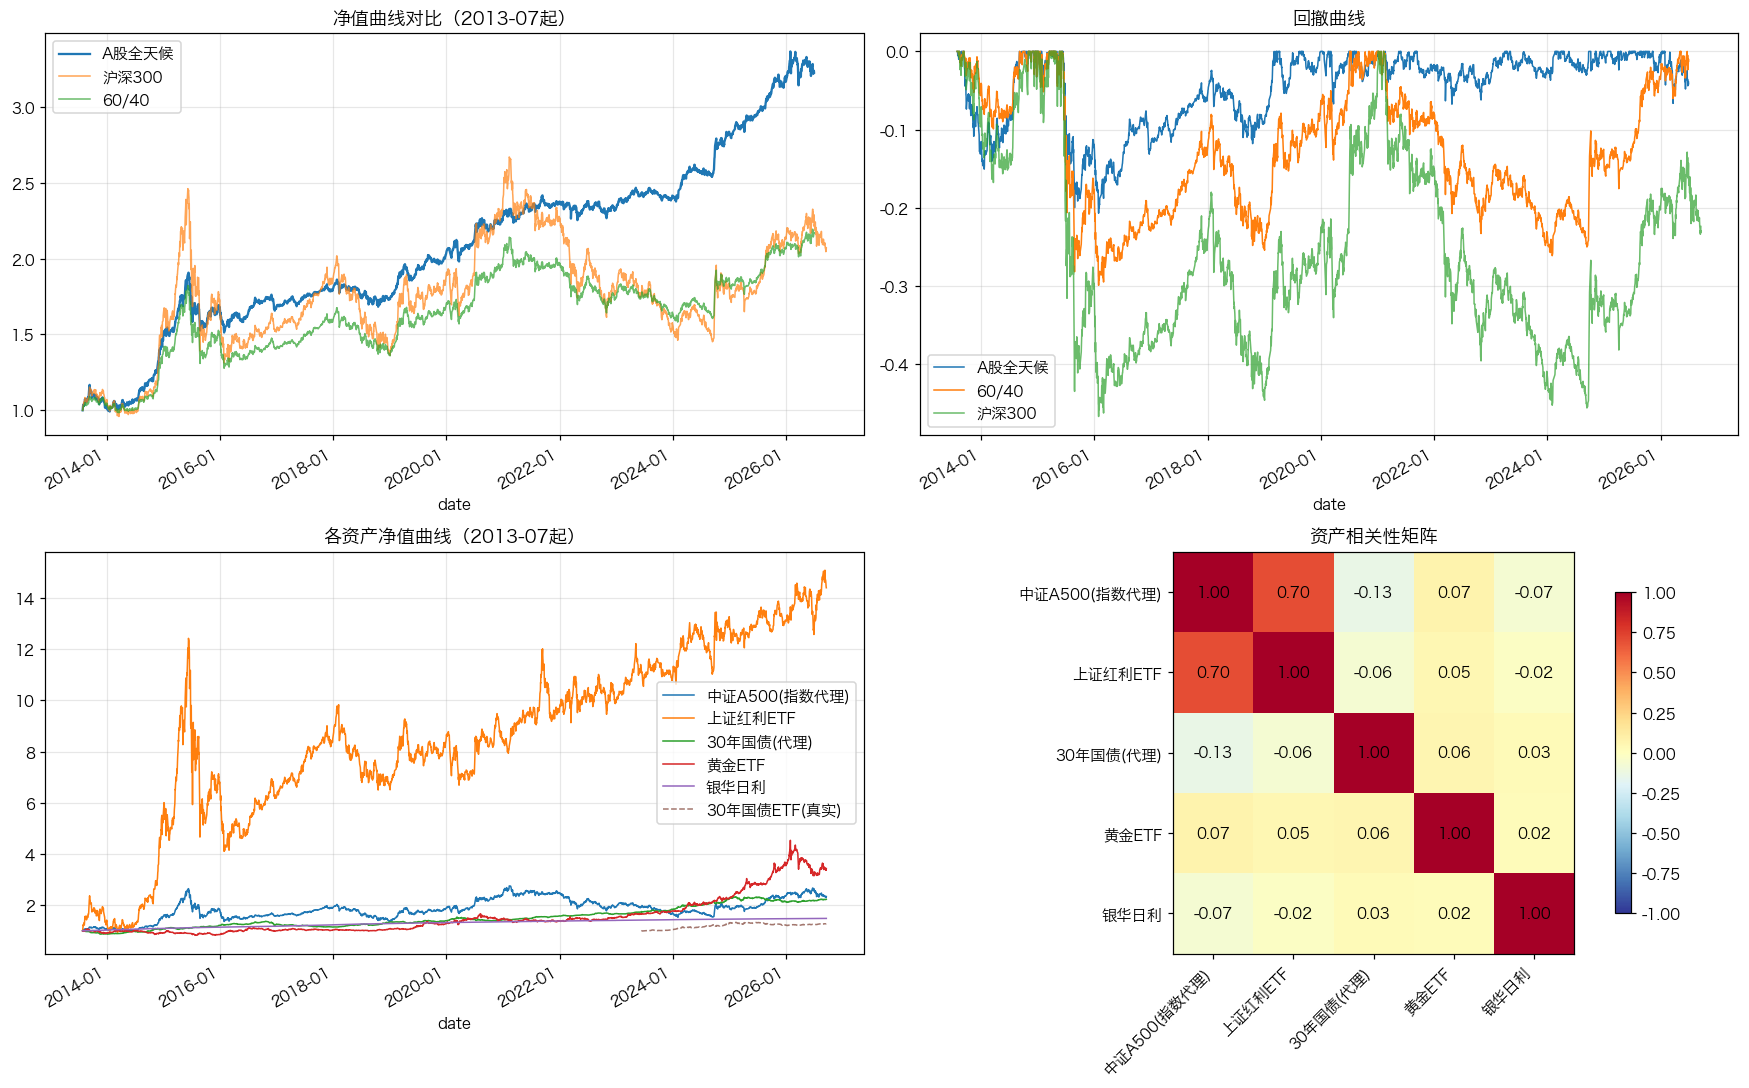

Chart saved to reports/generated/all_weather_a_share.png


In [6]:
PLOT_CODES = ['000510', '510880', '0030Y', '518880', '511880']
OUT_PNG = 'reports/generated/all_weather_a_share.png'

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

ax = axes[0, 0]
bt_aw.daily_nav.plot(ax=ax, label='A股全天候', linewidth=1.5)
if bench_300_nav is not None:
    bench_300_nav.plot(ax=ax, label='沪深300', linewidth=1, alpha=0.7)
bt_6040.daily_nav.plot(ax=ax, label='60/40', linewidth=1, alpha=0.7)
ax.set_title('净值曲线对比（2013-07起）')
ax.legend()
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

ax = axes[0, 1]
for nav_s, label in [(bt_aw.daily_nav, 'A股全天候'), (bt_6040.daily_nav, '60/40')]:
    dd = nav_s / nav_s.expanding().max() - 1
    dd.plot(ax=ax, label=label, linewidth=1)
if bench_300_nav is not None:
    dd300 = bench_300_nav / bench_300_nav.expanding().max() - 1
    dd300.plot(ax=ax, label='沪深300', linewidth=1, alpha=0.7)
ax.set_title('回撤曲线')
ax.legend()
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

ax = axes[1, 0]
for code in PLOT_CODES:
    if code in all_data:
        df = all_data[code]
        df = df[(df.index >= BT_START) & (df.index <= BT_END)]
        nav_i = df['close'] / df['close'].iloc[0]
        nav_i.plot(ax=ax, label=ALL_CODES.get(code, code), linewidth=1)
if '511090' in all_data:   # 真实30年国债ETF叠加参考
    df = all_data['511090']
    df = df[(df.index >= BT_START) & (df.index <= BT_END)]
    (df['close'] / df['close'].iloc[0]).plot(ax=ax, label='30年国债ETF(真实)', linewidth=1, linestyle='--', alpha=0.8)
ax.set_title('各资产净值曲线（2013-07起）')
ax.legend()
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

ax = axes[1, 1]
ret_df = pd.DataFrame()
for code in PLOT_CODES:
    if code in all_data:
        df = all_data[code]
        df = df[(df.index >= BT_START) & (df.index <= BT_END)]
        ret_df[ALL_CODES.get(code, code)] = df['close'].pct_change()
ret_df = ret_df.dropna()
corr = ret_df.corr()
im = ax.imshow(corr.values, cmap='RdYlBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr)))
ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center', fontsize=10)
ax.set_title('资产相关性矩阵')
fig.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
os.makedirs('reports/generated', exist_ok=True)
plt.savefig(OUT_PNG, dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to', OUT_PNG)


In [7]:
print('=== A股全天候组合 - 季度头寸（万元） ===')
pos = bt_aw.quarterly_pos.copy()
pos.index = pos.index.strftime('%Y-%m-%d')
print((pos / 10000).round(2).to_string())


=== A股全天候组合 - 季度头寸（万元） ===
            000510  510880  0030Y  518880  511880
date                                             
2013-07-29   25.00   10.00  30.00   15.00   20.00
2013-10-08   27.54   11.02  33.05   16.52   22.03
2014-01-02   25.77   10.31  30.92   15.46   20.62
2014-04-01   25.58   10.23  30.69   15.35   20.46
2014-07-01   26.73   10.69  32.08   16.04   21.39
2014-10-08   30.08   12.03  36.10   18.05   24.07
2015-01-05   37.99   15.20  45.59   22.79   30.39
2015-04-01   40.73   16.29  48.88   24.44   32.59
2015-07-01   42.61   17.04  51.13   25.57   34.09
2015-10-08   39.27   15.71  47.13   23.56   31.42
2016-01-04   40.72   16.29  48.86   24.43   32.57
2016-04-01   40.75   16.30  48.91   24.45   32.60
2016-07-01   40.98   16.39  49.17   24.59   32.78
2016-10-10   43.01   17.21  51.62   25.81   34.41
2017-01-03   42.15   16.86  50.58   25.29   33.72
2017-04-05   43.50   17.40  52.20   26.10   34.80
2017-07-03   43.78   17.51  52.53   26.27   35.02
2017-10-09   44.66   17

In [8]:
def monthly_returns(nav):
    ret = nav.pct_change().dropna()
    ret.index = pd.to_datetime(ret.index)
    monthly = ret.resample('M').apply(lambda x: (1+x).prod()-1)
    table = pd.DataFrame({
        'year': monthly.index.year,
        'month': monthly.index.month,
        'return': monthly.values
    })
    pivot = table.pivot(index='year', columns='month', values='return')
    pivot.columns = [f'{m}月' for m in pivot.columns]
    return pivot

print('=== A股全天候 月度收益 ===')
mr_aw = monthly_returns(bt_aw.daily_nav)
print((mr_aw * 100).round(2).to_string())

if bench_300_nav is not None:
    print('\n=== 沪深300 月度收益 ===')
    mr_300 = monthly_returns(bench_300_nav)
    print((mr_300 * 100).round(2).to_string())


=== A股全天候 月度收益 ===
        1月    2月    3月    4月    5月    6月    7月    8月    9月   10月   11月    12月
year                                                                         
2013   NaN   NaN   NaN   NaN   NaN   NaN  1.31  5.59  2.17 -1.20 -0.27  -4.07
2014 -1.83  2.25 -1.88  1.77  1.65  1.56  6.03  0.30  5.42  2.77  7.23  12.20
2015  2.04  1.58  4.90  8.87  2.35 -2.51 -6.70 -2.92 -2.10  5.40 -0.54   2.93
2016 -8.54  1.09  5.13 -0.40 -1.01  1.78  3.15  1.85 -0.10  1.27  0.82  -3.82
2017  0.60  1.49  0.41 -0.49 -0.05  2.08  0.64  0.37  0.55  0.81 -0.00   0.09
2018  2.41 -1.60 -0.40 -0.81  0.96 -2.36  0.97 -3.02  1.40 -2.28  1.16   0.38
2019  2.29  5.42  2.78 -1.19 -1.78  3.41  0.74  2.10 -0.53 -0.34 -0.08   3.41
2020  0.58  1.31 -2.12  2.61 -0.55  2.51  5.12  0.71 -2.82  0.48  1.55   2.09
2021  0.06 -0.16 -0.57  1.59  2.58 -1.02  0.06  1.63 -0.64 -0.62  0.30   1.14
2022 -2.13  1.49 -1.07 -1.31  0.87  2.32 -1.67  0.51 -1.76 -1.82  2.94  -0.15
2023  2.50 -0.23  1.31  1.04 -1.13  0.47  1.7